In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['axes.unicode_minus'] = False


In [2]:
df = pd.read_csv('data/california.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [15]:
df = df.drop(columns=['ocean_proximity'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [16]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
dtype: int64

In [17]:
df = df.dropna()
df.isna().sum().sum()

np.int64(0)

In [18]:
import tensorflow as tf
from tensorflow.keras import Sequential, layers
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [19]:
# 데이터 분리

X = df.drop('median_house_value', axis=1)
y= df['median_house_value']

print(X.shape)
print(y.shape)

(20433, 8)
(20433,)


In [20]:
# 데이터 분리 및 스케일링

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(16346, 8)
(4087, 8)


In [ ]:
# 출력층의 활성함수
# 이진분류: sigmoid
# 회귀: 없음
# 다중분류: softemax

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)    # 값을 예측하는 회귀 모델로써 아웃풋은 1개이고, 활성함수는 지정하지 않는다
    ])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',  # mean squared error
    metrics=['mae']
)

model.summary()

C:\Users\heyum\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,521 (45.00 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# Learning Rate를 감소시킴
reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5, # 학습률을 절반으로 줄임
    patience=5,
    min_lr=0.00001,
    verbose=1
)

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=200,
    batch_size=64,
    callbacks=[early_stop, reduce],
    verbose=1
)

Epoch 1/200
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 54555316224.0000 - mae: 203475.3125 - val_loss: 49062518784.0000 - val_mae: 189672.0625 - learning_rate: 0.0010
Epoch 2/200
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 27491909632.0000 - mae: 128912.0859 - val_loss: 13710695424.0000 - val_mae: 84926.5000 - learning_rate: 0.0010
Epoch 3/200
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 11451806720.0000 - mae: 78087.3906 - val_loss: 10304413696.0000 - val_mae: 73293.8125 - learning_rate: 0.0010
Epoch 4/200
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 9324844032.0000 - mae: 69872.4531 - val_loss: 8562715648.0000 - val_mae: 66724.3828 - learning_rate: 0.0010
Epoch 5/200
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8079732224.0000 - mae: 64773.5078 - val_loss: 7382228480.0000 - val_mae: 62152.0352 - learning_rate: 0.0010
Epoch 6/200
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7138536448.0000 - mae: 61185.1953 - val_loss: 6540163072.0000 - val_mae: 58457.2617 -

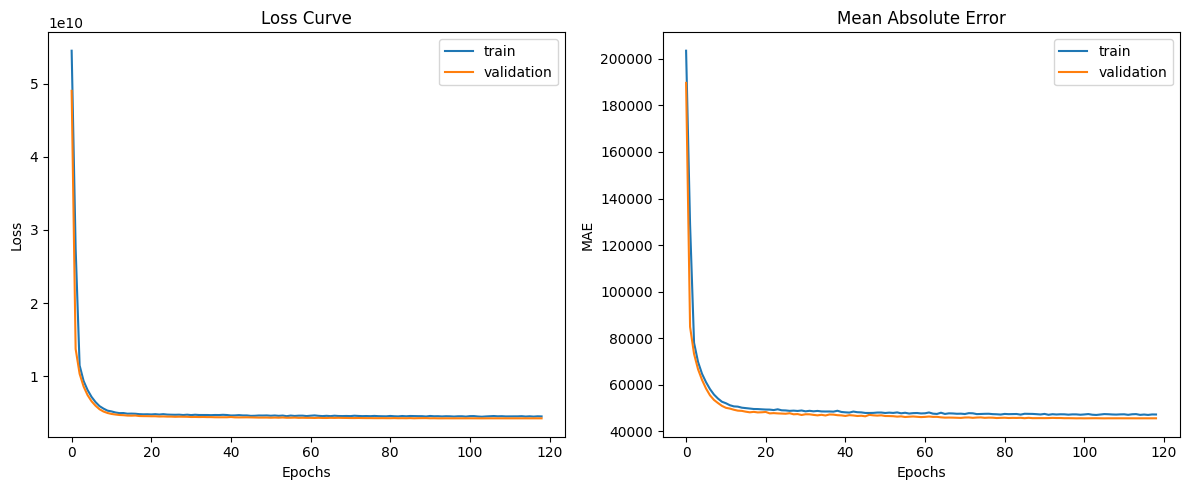

In [23]:
# 학습률 시각화
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='train')
plt.plot(history.history['val_mae'], label='validation')
plt.title('Mean Absolute Error')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()